In [2]:
import pandas as pd

#define the path to the clean csv
data_path = "E:\Personal\Data Science\mexico-real-estate-combined-clean.csv"

#Load data
df = pd.read_csv(data_path)

#Verify the Load
print(f"dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
print(df.info())
df.head()

dimensions: 1736 rows and 6 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1736 non-null   object 
 1   state          1736 non-null   object 
 2   lat            1736 non-null   float64
 3   lon            1736 non-null   float64
 4   area_m2        1736 non-null   float64
 5   price_usd      1736 non-null   float64
dtypes: float64(4), object(2)
memory usage: 81.5+ KB
None


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


Text(0.5, 1.0, 'Distribution of Property Prices')

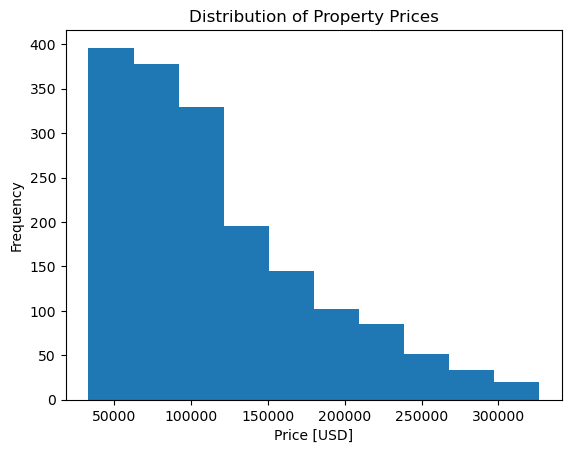

In [7]:
#import matplotlib
import matplotlib.pyplot as plt

#Create a histogram for price
fig, ax = plt.subplots()

#Create a histogram for price_usd
ax.hist(df["price_usd"])

#Add axis Labels and Title
ax.set_ylabel("Frequency")
ax.set_xlabel("Price [USD]")
ax.set_title("Distribution of Property Prices")

Text(0.5, 1.0, 'Distribution of Property Sizes')

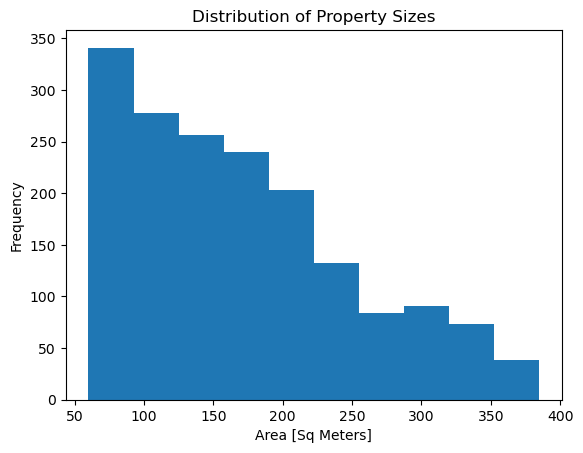

In [10]:
#Create a histogram for area_m2
fig, ax = plt.subplots()

#Create a histogram of "area_m2"
ax.hist(df["area_m2"])

#Add labels and Title
ax.set_xlabel("Area [Sq Meters]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Sizes")

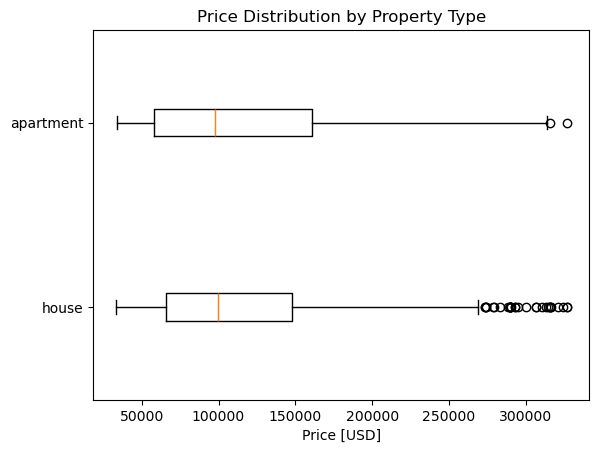

In [11]:
# 1. Get the unique category names on the column "property_type"
prop_types = df["property_type"].unique()

# 2. Prepare the data: Create a list of price arrays, one for each type
data_by_type = [df[df["property_type"] == label]["price_usd"] for label in prop_types]

# 3. Plot
fig, ax = plt.subplots()

# Pass the data list and the labels list
ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)

ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price [USD]")


plt.show()

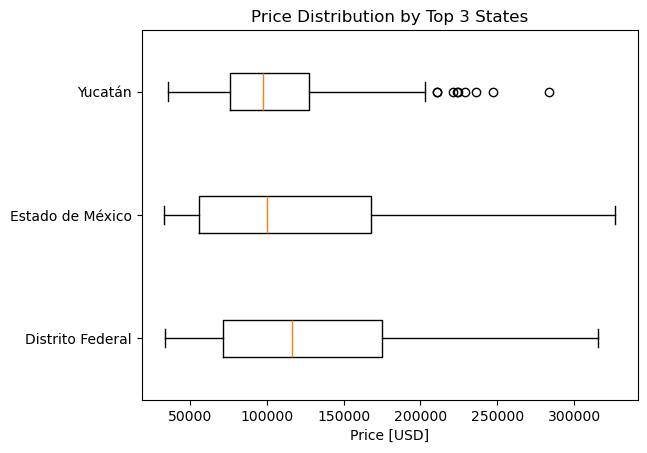

In [12]:
# 1. Define your selected states
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
    .index
    .tolist()
)

# 2. Prepare the data
data_by_state = [
    df[df["state"] == state]["price_usd"]
    for state in selected_states
]

# 3. Plot
fig, ax = plt.subplots()

ax.boxplot(
    data_by_state,
    tick_labels=selected_states,
    vert=False
)

ax.set_title("Price Distribution by Top 3 States")
ax.set_xlabel("Price [USD]")

plt.show()

In [14]:
#Ranking the 3 boxplots by Width
# Calculate the IQR (width of each box) for each state
iqr_by_state = {
    state: df[df["state"] == state]["price_usd"].quantile(0.75)
    - df[df["state"] == state]["price_usd"].quantile(0.25)
    for state in selected_states
}

# Rank states by box width, largest to smallest
ranked_states = sorted(
    iqr_by_state.items(),
    key=lambda x: x[1],
    reverse=True
)

# Display ranking
for rank, (state, iqr) in enumerate(ranked_states, start=1):
    print(f"{rank}. {state}: IQR = ${iqr:,.2f}")

1. Estado de México: IQR = $112,016.11
2. Distrito Federal: IQR = $103,401.30
3. Yucatán: IQR = $50,983.46


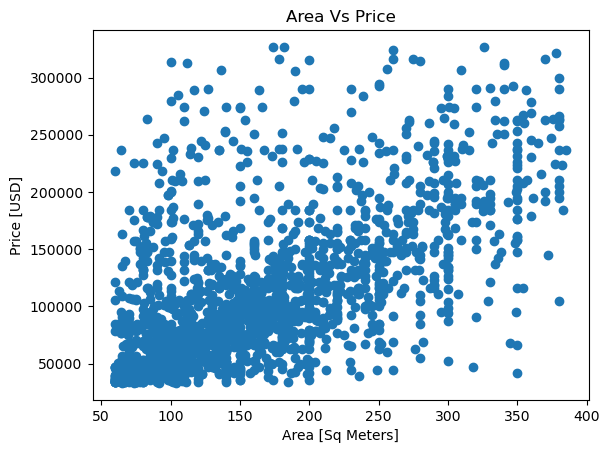

In [18]:
#Scatter_plot

#Create the Figure and Axes Objects
fig, ax = plt.subplots()

#Create the specific axes objects
ax.scatter(x=df["area_m2"], y=df["price_usd"])

#Set the labels and title
ax.set_xlabel("Area [Sq Meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area Vs Price")

plt.show()

Original: 1736 rows
Cleaned: 1365 rows
Removed: 371rows


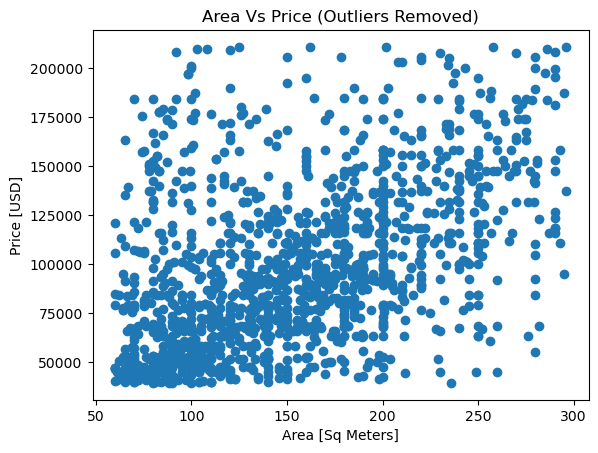

In [21]:
#Cleaned data after handling outliers

#Define cutoff percentages
lower_cut = 0.05 #Remove bottom 5%
upper_cut = 0.90 #Keep upto the 90th percentile

#Filter the data
df_clean = (
    df[
        (df["price_usd"]>df["price_usd"].quantile(lower_cut))&
        (df["price_usd"]<df["price_usd"].quantile(upper_cut))&
        (df["area_m2"]<df["area_m2"].quantile(upper_cut))
    ]
)

#Show what changed
print(f"Original: {len(df)} rows")
print(f"Cleaned: {len(df_clean)} rows")
print(f"Removed: {len(df)- len(df_clean)}rows")

#Plot
fig, ax = plt.subplots()
ax.scatter(df_clean["area_m2"], df_clean["price_usd"])
ax.set_xlabel("Area [Sq Meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area Vs Price (Outliers Removed)")
plt.show()
    

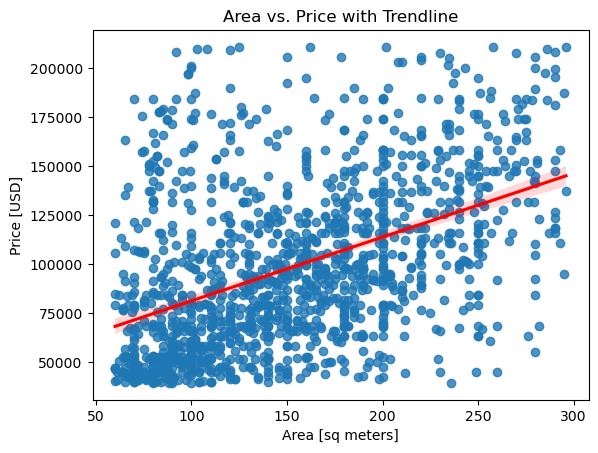

In [23]:
# import seaborn library
import seaborn as sns

# Create figure and axis explicitly
fig, ax = plt.subplots()

# Use Seaborn to plot scatter + trendline
sns.regplot(
    data=df_clean, 
    x="area_m2", 
    y="price_usd", 
    line_kws={"color": "red"},  # Make the line distinct
    ax=ax  # Pass the axis to seaborn
)

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price with Trendline")
plt.show()

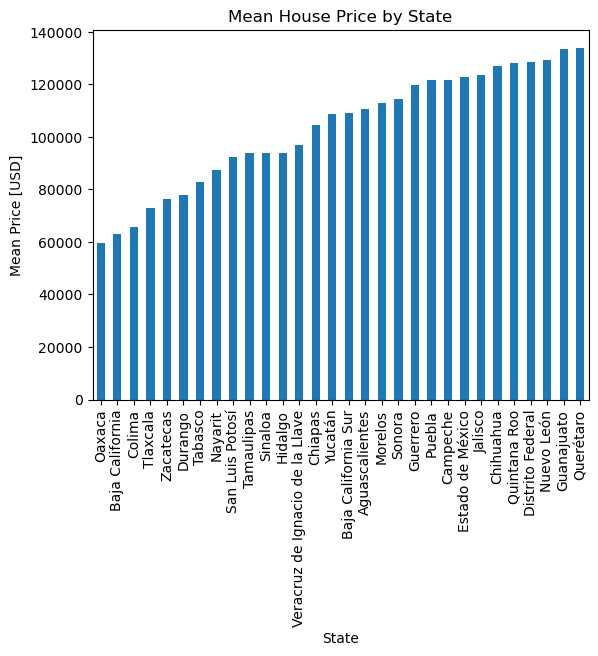

In [26]:
#ggregate data using groupby
mean_price_by_state = (
    df.groupby("state") ["price_usd"]
    .mean()
    .sort_values(ascending=True)
)

#Create figure and Axes
fig, ax = plt.subplots()

#Pandas plot method for explicit axes
mean_price_by_state.plot(
    kind="bar",
    ax=ax
)

#Customixe labels and title using Matplotlib methods
ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.set_title("Mean House Price by State")

plt.show()

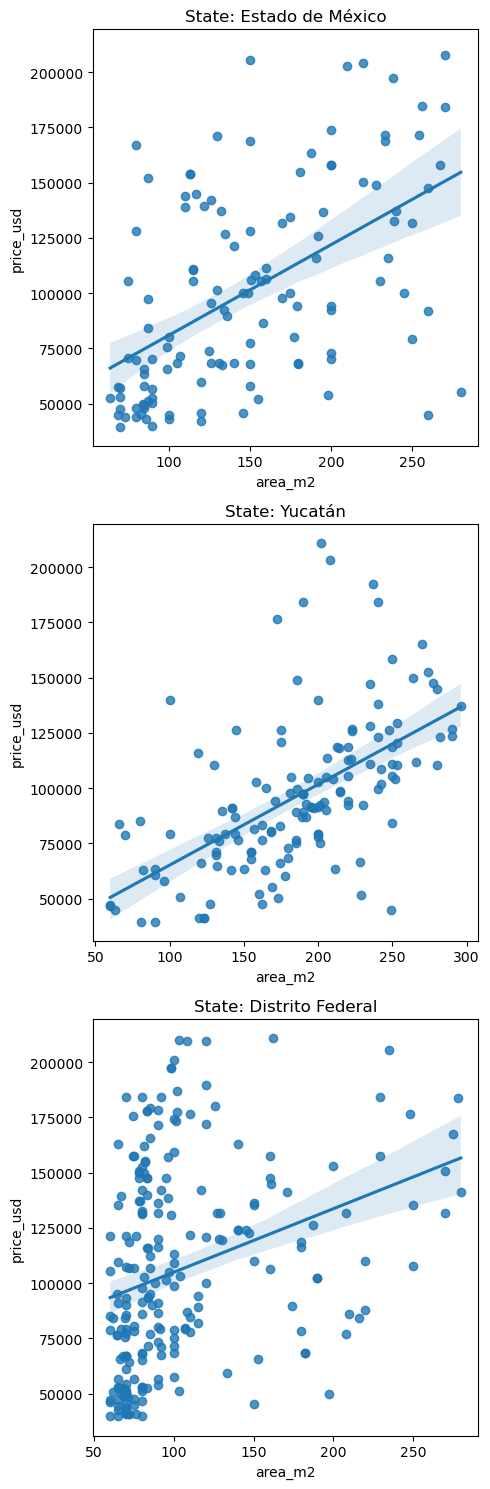

In [27]:
## 1. Create your custom figure and axes
fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharey=True)

# 2. Create a list of the top 3 states
top_states = selected_states

# 3. Filter df_clean to include only these states
df_states = df_clean[df_clean["state"].isin(top_states)]

# 4. Loop through the states and plot on each specific axis
states = df_states["state"].unique()

for ax, state in zip(axes, states):
    # Filter data for the current state
    subset = df_states[df_states["state"] == state]
    
    # Use regplot (Axes-level) which ACCEPTS 'ax='
    sns.regplot(
        data=subset,
        x="area_m2",  # <--- "area_m2"
        y="price_usd",  # <--- "price_usd" 
        color='tab:blue', # Optional: keep colors consistent
        ax=ax # <--- This is where you pass the axis explicitly
    )
    
    ax.set_title(f"State: {state}")

plt.tight_layout()
plt.show()